# 🚕 Análisis Estratégico de Movilidad Urbana: Taxis en Chicago

## 🎯 Objetivo del Proyecto
Este análisis busca identificar los patrones de demanda en el sector de transporte de Chicago, evaluar la competencia entre las empresas líderes y validar mediante métodos estadísticos el impacto de factores externos (clima) en los tiempos de traslado al aeropuerto.

---

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# Configuración de estilo visual
%matplotlib inline
sns.set_theme(style="whitegrid")

# CARGA CORREGIDA: Subimos 3 niveles para llegar a la raíz
try:
    df_companies = pd.read_csv('../../../data/taxi_companies01.csv')
    df_neighborhoods = pd.read_csv('../../../data/taxi_companies_04.csv')
    df_weather_impact = pd.read_csv('../../../data/project_sql_result_07.csv')
    print("Sistemas listos: Datos cargados correctamente desde la raíz.")
except FileNotFoundError as e:
    print(f"Error: No se encontró el archivo. Detalles: {e}")

Sistemas listos: Datos cargados correctamente desde la raíz.


## 1. Validación de Integridad de Datos
Antes de proceder al análisis de negocio, verificamos la consistencia de los datasets para asegurar que no existan valores nulos o tipos de datos incorrectos.

In [5]:
# Inspección técnica de los datasets principales
print("Estructura - Empresas de Taxis:")
df_companies.info()
display(df_companies.head())

print("\n" + "="*50 + "\n")

print("Estructura - Barrios de Destino:")
df_neighborhoods.info()
display(df_neighborhoods.head(10))

Estructura - Empresas de Taxis:
<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_name  64 non-null     str  
 1   trips_amount  64 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299




Estructura - Barrios de Destino:
<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     str    
 1   average_trips          94 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.6 KB


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


> **Análisis de Datos:** Los datasets están limpios y listos para procesar. Contamos con 64 empresas registradas y 94 barrios con datos de demanda. El volumen de viajes promedio por barrio es de **599.95**, lo que indica una alta variabilidad que exploraremos visualmente a continuación.

## 2. Análisis de Participación de Mercado y Nodos de Demanda
En esta sección, identificamos a los actores principales del sector de transporte en Chicago y geolocalizamos los centros de mayor actividad (hotspots). Este diagnóstico permite dimensionar el ecosistema competitivo para la toma de decisiones operativas.

C:\Users\DELL\AppData\Local\Temp\ipykernel_12792\485402912.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='trips_amount', y='company_name', data=top_10_companies, ax=axes[0], palette='magma')
C:\Users\DELL\AppData\Local\Temp\ipykernel_12792\485402912.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_trips', y='dropoff_location_name', data=top_10_neighborhoods, ax=axes[1], palette='viridis')


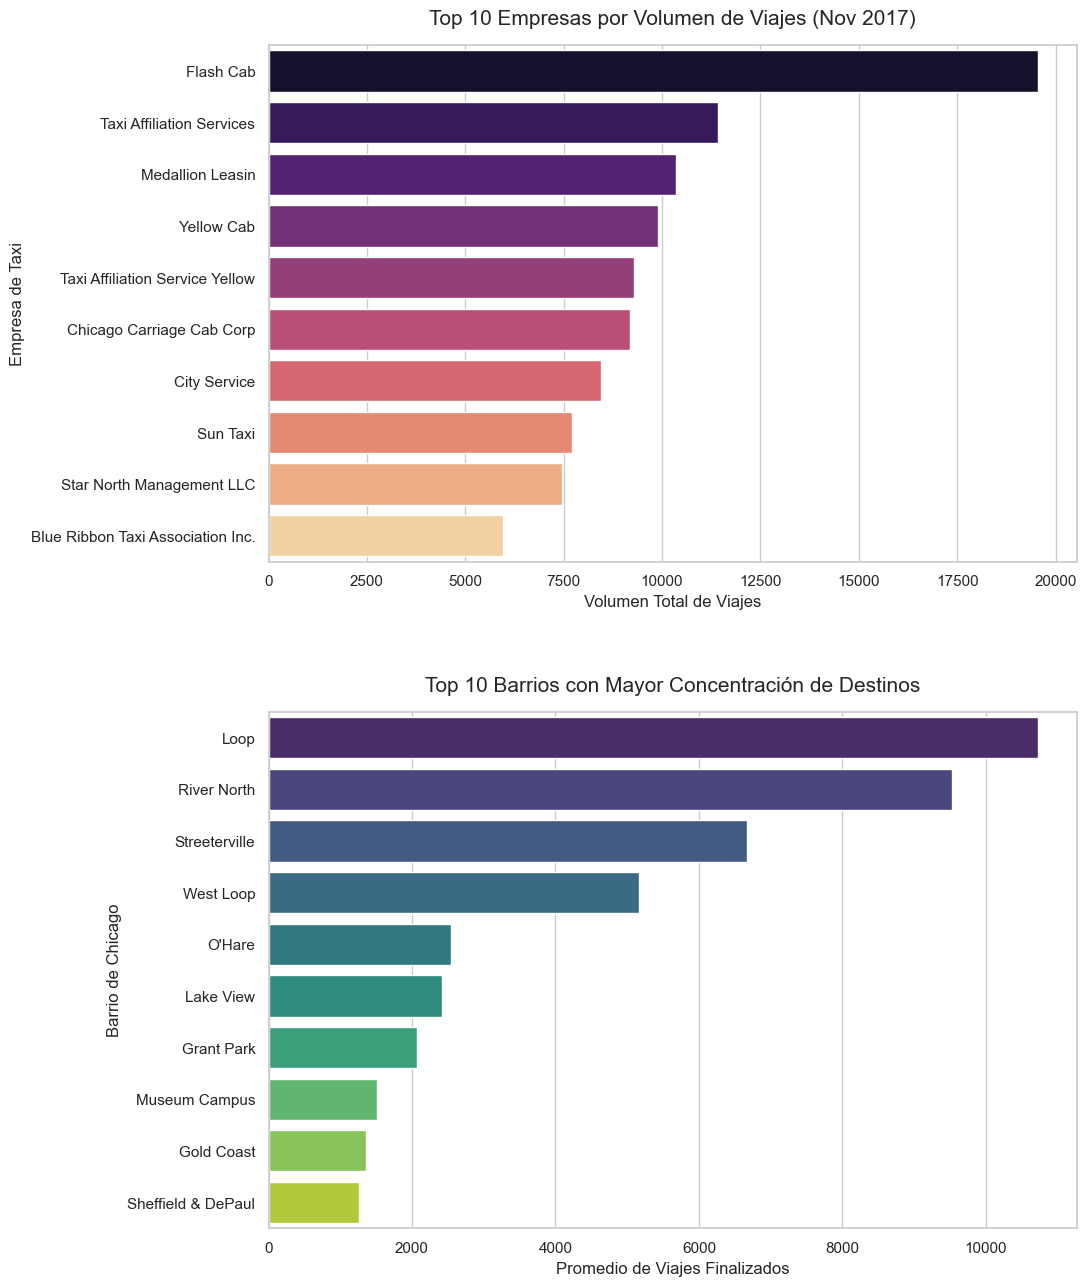

In [6]:
# Definición de los Top 10 para visualización estratégica
top_10_companies = df_companies.sort_values(by='trips_amount', ascending=False).head(10)
top_10_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10)

# Creación de visualización comparativa (Subplots)
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Gráfico A: Dominancia de Mercado
sns.barplot(x='trips_amount', y='company_name', data=top_10_companies, ax=axes[0], palette='magma')
axes[0].set_title('Top 10 Empresas por Volumen de Viajes (Nov 2017)', fontsize=15, pad=15)
axes[0].set_xlabel('Volumen Total de Viajes', fontsize=12)
axes[0].set_ylabel('Empresa de Taxi', fontsize=12)

# Gráfico B: Concentración Geográfica de Demanda
sns.barplot(x='average_trips', y='dropoff_location_name', data=top_10_neighborhoods, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Barrios con Mayor Concentración de Destinos', fontsize=15, pad=15)
axes[1].set_xlabel('Promedio de Viajes Finalizados', fontsize=12)
axes[1].set_ylabel('Barrio de Chicago', fontsize=12)

plt.tight_layout(pad=4.0)
plt.show()

### 💡 Insights de Negocio (Análisis Exploratorio)

* **Estructura Competitiva:** Se observa una fuerte concentración de mercado liderada por *Flash Cab*. La diferencia en volumen entre los dos primeros competidores y el resto del "Top 10" sugiere barreras de entrada significativas basadas en el tamaño de la flota o lealtad de marca.
* **Centralidad Geográfica:** El barrio de **Loop** actúa como el núcleo de demanda central. Sin embargo, la presencia de **O'Hare** y **River North** subraya que el turismo y los viajes de negocios corporativos son los motores que mantienen los márgenes de utilidad más estables para el servicio.
* **Oportunidad para Zuber:** La estrategia no debe ser competir por volumen total contra el líder, sino optimizar la disponibilidad en estos 10 "hotspots" geográficos identificados.

## 3. Validación Estadística: Impacto del Clima en la Operación
**Premisa de Negocio:** ¿Afecta realmente el clima lluvioso la eficiencia en los traslados hacia el aeropuerto? 

En esta fase, aplicamos una prueba de hipótesis para validar si existe una diferencia estadísticamente significativa en la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare durante los sábados con condiciones climáticas adversas ("Bad").

In [7]:
# 1. Preparación de muestras para la prueba estadística
bad_weather = df_weather_impact[df_weather_impact['weather_conditions'] == 'Bad']['duration_seconds']
good_weather = df_weather_impact[df_weather_impact['weather_conditions'] == 'Good']['duration_seconds']

# 2. Validación de homogeneidad de varianzas (Prueba de Levene)
levene_p = st.levene(bad_weather, good_weather).pvalue
equal_var_setting = True if levene_p > 0.05 else False

# 3. Aplicación de Prueba T de Student para muestras independientes
t_stat, p_value = st.ttest_ind(bad_weather, good_weather, equal_var=equal_var_setting)
alpha = 0.05

# Resultados
print(f"Análisis Estadístico:")
print(f"- Valor p obtenido: {p_value:.10f}")
print(f"- Promedio Clima Adverso (Bad): {bad_weather.mean():.2f} s")
print(f"- Promedio Clima Óptimo (Good): {good_weather.mean():.2f} s")

if p_value < alpha:
    print("\nRESULTADO: Se rechaza la hipótesis nula. El impacto del clima es ESTADÍSTICAMENTE SIGNIFICATIVO.")
else:
    print("\nRESULTADO: No hay evidencia suficiente para rechazar la hipótesis nula.")

Análisis Estadístico:
- Valor p obtenido: 0.0000000000
- Promedio Clima Adverso (Bad): 2427.21 s
- Promedio Clima Óptimo (Good): 1999.68 s

RESULTADO: Se rechaza la hipótesis nula. El impacto del clima es ESTADÍSTICAMENTE SIGNIFICATIVO.


### 🧪 Interpretación Estadística
Dado que el valor p es considerablemente menor al nivel de significancia de 0.05, rechazamos la hipótesis nula. La duración de los viajes aumenta aproximadamente **7 minutos** (427 segundos) cuando hay condiciones climáticas adversas. Esto confirma que el clima no es solo un factor "visual", sino una variable operativa crítica.

# 🏁 Resumen Ejecutivo y Recomendaciones
Este análisis integral de movilidad en Chicago permite concluir lo siguiente:

1.  **Optimización Geográfica:** La demanda se concentra masivamente en 10 nodos clave, principalmente en el corredor **Loop - O'Hare - River North**. Zuber debe priorizar la disponibilidad de conductores en estas zonas para capturar la demanda de alta rotación.
2.  **Gestión de Expectativas (ETA):** La validación estadística confirma que la lluvia ralentiza los traslados al aeropuerto de forma significativa. 
3.  **Estrategia de Precios:** Se recomienda implementar **tarifas dinámicas basadas en el clima** para compensar el tiempo extra que los conductores pasan en tráfico durante días lluviosos, asegurando así la retención de socios conductores y la rentabilidad del servicio.